|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 2:</h2>|<h1>Batching<h1>|
|<h2>Section:</h2>|<h1>Static batching<h1>|
|<h2>Lecture:</h2>|<h1><b>What a static batch throws away<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

rng = np.random.default_rng(0)

# The slot that waited

Batching is free. To collect a batch is not free.

A [static batch](../../GLOSSARY.md#static-batching) starts together and ends together. It runs until its **slowest**
member finishes. A sequence that finishes early holds its slot and does
nothing.

You need no GPU to see the damage. The length distribution causes it, not the
hardware.

In [2]:
# real traffic is roughly log-normal: a lot of short replies, a long tail
lengths = rng.lognormal(mean=np.log(120), sigma=0.9, size=20000).astype(int) + 1

print(f'median {np.median(lengths):.0f} tokens')
print(f'mean   {lengths.mean():.0f}')
print(f'p99    {np.percentile(lengths,99):.0f}')
print(f'max    {lengths.max()}')
print(f'\nthe p99 is {np.percentile(lengths,99)/np.median(lengths):.0f}x the median. That ratio is the problem.')

median 120 tokens
mean   180
p99    960
max    4182

the p99 is 8x the median. That ratio is the problem.


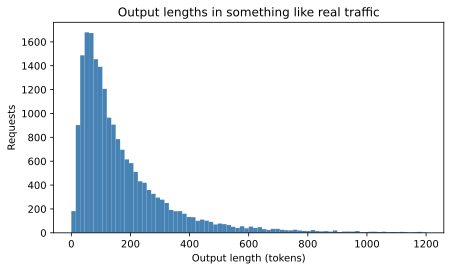

In [3]:
plt.figure(figsize=(7,3.8))
plt.hist(lengths, bins=80, range=(0,1200), color='steelblue')
plt.xlabel('Output length (tokens)')
plt.ylabel('Requests')
plt.title('Output lengths in something like real traffic')
plt.show()

### What one static batch wastes

Take B requests. The batch runs for `max(lengths)` steps. The useful work is
`sum(lengths)`. A finished sequence holds each remaining slot open.

In [4]:
def static_waste(batch_lengths):
  steps = batch_lengths.max()
  slots = steps * len(batch_lengths)
  useful = batch_lengths.sum()
  return 1 - useful/slots

for batch_size in (2,4,8,16,32,64,128):
  wasted = np.mean([static_waste(rng.choice(lengths, batch_size)) for _ in range(400)])
  print(f'batch {batch_size:>4}: {100*wasted:5.1f}% of decoded slots wasted')

batch    2:  26.3% of decoded slots wasted
batch    4:  46.3% of decoded slots wasted
batch    8:  59.5% of decoded slots wasted
batch   16:  69.0% of decoded slots wasted
batch   32:  75.4% of decoded slots wasted
batch   64:  80.9% of decoded slots wasted
batch  128:  84.4% of decoded slots wasted


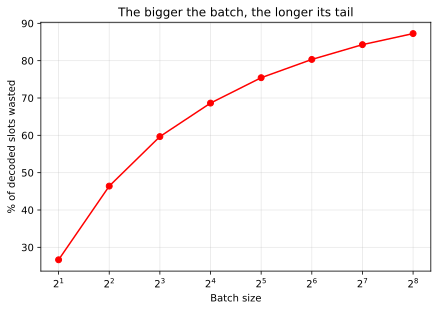

In [5]:
batch_sizes = np.array([2,4,8,16,32,64,128,256])
mean_wastes = np.array([np.mean([static_waste(rng.choice(lengths, int(batch_size))) for _ in range(400)])
                  for batch_size in batch_sizes])

plt.figure(figsize=(7,4.5))
plt.plot(batch_sizes, 100*mean_wastes, 'ro-')
plt.xscale('log', base=2)
plt.xlabel('Batch size')
plt.ylabel('% of decoded slots wasted')
plt.title('The bigger the batch, the longer its tail')
plt.grid(alpha=.3)
plt.show()

### The direction of that curve is the problem

A larger batch gives better throughput and worse [padding](../../GLOSSARY.md#padding) waste at the same
time. One cause produces both. A larger sample holds an outlier more often,
and the outlier sets the length of the batch.

Put the two effects together. The throughput you receive is the curve from the
last notebook, multiplied by one minus this curve.

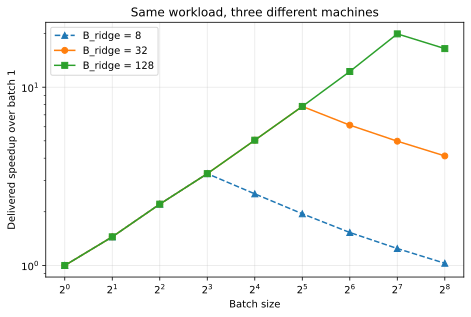

 B_ridge  best batch  delivered   of the   kept
       8           8       3.3x       8x    41%
      16          16       5.0x      16x    32%
      32          32       7.8x      32x    24%
      64          64      12.2x      64x    19%
     128         128      19.9x     128x    16%


In [6]:
# Do not memorise throughput against batch. It is Part 1's roofline, in batch
# units:
#
#     step(B) = max(weight read, B x per-sequence work)
#     so      throughput(B) / throughput(1) = min(B, B_ridge)
#
# B_ridge is the batch at which the step stops being free. It is the only
# hardware number here. You measured it in part2_pad_freeSequences. It is the
# largest batch whose step still costs what batch 1 costs.

def raw_speedup(batch_size, B_ridge):
  return np.minimum(batch_size, B_ridge)

all_batch_sizes = np.array([1,2,4,8,16,32,64,128,256])
waste_fractions = np.array([np.mean([static_waste(rng.choice(lengths, int(batch_size))) for _ in range(400)])
                for batch_size in all_batch_sizes])

plt.figure(figsize=(7.5,4.6))
for B_ridge, style in ((8,'^--'), (32,'o-'), (128,'s-')):
  plt.plot(all_batch_sizes, raw_speedup(all_batch_sizes, B_ridge)*(1-waste_fractions), style,
           label=f'B_ridge = {B_ridge}')
plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('Batch size')
plt.ylabel('Delivered speedup over batch 1')
plt.title('Same workload, three different machines')
plt.legend()
plt.grid(alpha=.3)
plt.show()

print(f"{'B_ridge':>8} {'best batch':>11} {'delivered':>10} {'of the':>8} {'kept':>6}")
for B_ridge in (8, 16, 32, 64, 128):
  delivered = raw_speedup(all_batch_sizes, B_ridge)*(1-waste_fractions)
  best_index = int(np.argmax(delivered))
  print(f'{B_ridge:>8} {all_batch_sizes[best_index]:>11} {delivered[best_index]:>9.1f}x {B_ridge:>7}x '
        f'{100*delivered[best_index]/B_ridge:>5.0f}%')

### Read the `kept` column down the page

`B_ridge` is the only property of your card in this notebook. It is the batch
at which a decode step stops being free. It comes from Part 1's roofline. A
machine with more arithmetic per byte of bandwidth has a larger one.

Now see what a larger one buys. Sixteen times the `B_ridge` gives about six
times the delivered throughput. The fraction you keep falls from about 40
percent to about 16 percent.

That is not a measurement error. A higher `B_ridge` permits a larger batch. A
larger batch holds a long outlier more often. The outlier sets the length of
the batch. **Padding waste takes a larger share of a faster machine.**

So do not carry away a batch size or a speedup. Carry this away:

> delivered = `min(B, B_ridge)` x `(1 - waste(B))`
>
> The first factor is your hardware. The second is your traffic. Better
> hardware alone gives less and less, and it gives less the more you buy.

Measure `B_ridge` for your own card in `part2_pad_freeSequences`. Put your
value in the table above. The shape stays the same. Your row does not.

### None of this is a hardware problem

You have no kernel to write. A scheduling decision left the slots idle. The
scheduler fixed the batch when the batch started.

So do not fix it. Let a finished sequence leave when it emits its stop token.
Let a waiting sequence take the slot on the next step. That is **continuous
batching**, from Orca (OSDI '22). It is the largest single throughput win in
this course.

The next section builds it.

    ./vc guide 5